In [1]:
import polars as pl

from ohlc_dss_model.data import load_parquet, remove_incomplete_days, intraday_session_tagging, session_tagging, filter_valid_sessions

from ohlc_dss_model.features import (
    aggregate_sessions, yang_zhang, 
    PRE_NY_SPEC, FULL_DAY_SPEC, 
    calculate_excursion_bands, assign_direction, 
    detect_pivots, pivot_extraction
)

from ohlc_dss_model.utils import convert_to_timezone, plot_session

from datetime import date

In [2]:
raw_data = load_parquet()
raw_data = convert_to_timezone(raw_data)
raw_data = session_tagging(raw_data)
raw_data = intraday_session_tagging(raw_data)
raw_data = remove_incomplete_days(raw_data)

# For aggregated session data
aggregated_data = aggregate_sessions(raw_data)
aggregated_data = filter_valid_sessions(aggregated_data)

aggregated_data = aggregated_data.with_columns(
    pl.col("O_Asia").alias("O_Ref")
)

aggregated_data = yang_zhang(aggregated_data, FULL_DAY_SPEC, mode="historical")
aggregated_data = yang_zhang(aggregated_data, PRE_NY_SPEC, mode="today")

aggregated_data = assign_direction(aggregated_data)
aggregated_data = calculate_excursion_bands(aggregated_data)

print(aggregated_data.drop_nulls().head(2))
print(raw_data.head(2))

shape: (2, 33)
┌────────────┬────────┬──────────┬─────────┬───┬────────────┬────────────┬────────────┬────────────┐
│ Session    ┆ O_New  ┆ O_London ┆ O_Asia  ┆ … ┆ Band_FE_Ne ┆ Band_FE_Ne ┆ Band_FE_Po ┆ Band_FE_Po │
│ ---        ┆ York   ┆ ---      ┆ ---     ┆   ┆ g_Upper    ┆ g_Lower    ┆ s_Upper    ┆ s_Lower    │
│ date       ┆ ---    ┆ f64      ┆ f64     ┆   ┆ ---        ┆ ---        ┆ ---        ┆ ---        │
│            ┆ f64    ┆          ┆         ┆   ┆ f64        ┆ f64        ┆ f64        ┆ f64        │
╞════════════╪════════╪══════════╪═════════╪═══╪════════════╪════════════╪════════════╪════════════╡
│ 2016-03-02 ┆ 4329.0 ┆ 4341.5   ┆ 4334.5  ┆ … ┆ 4268.67976 ┆ 4255.33819 ┆ 4413.66180 ┆ 4400.32023 │
│            ┆        ┆          ┆         ┆   ┆ 3          ┆ 5          ┆ 5          ┆ 7          │
│ 2016-03-03 ┆ 4329.0 ┆ 4334.75  ┆ 4326.75 ┆ … ┆ 4264.83223 ┆ 4251.63121 ┆ 4401.86878 ┆ 4388.66777 │
│            ┆        ┆          ┆         ┆   ┆            ┆ 3          ┆ 7

In [3]:
print(aggregated_data.columns)

['Session', 'O_New York', 'O_London', 'O_Asia', 'H_New York', 'H_London', 'H_Asia', 'L_New York', 'L_London', 'L_Asia', 'C_New York', 'C_London', 'C_Asia', 'O_Ref', 'Sigma_Historical', 'Sigma_Today', 'Z_Body', 'Z_Sigma', 'Tau', 'Direction', '_delta_t', 'Band_AE_Pos_Center', 'Band_AE_Neg_Center', 'Band_FE_Pos_Center', 'Band_FE_Neg_Center', 'Band_AE_Neg_Upper', 'Band_AE_Neg_Lower', 'Band_AE_Pos_Upper', 'Band_AE_Pos_Lower', 'Band_FE_Neg_Upper', 'Band_FE_Neg_Lower', 'Band_FE_Pos_Upper', 'Band_FE_Pos_Lower']


### **Introduction**
In this research we will explore some ideas on how we would capture intraday price movement and the interactions with the excursion bands.

The first approach we will explore is the idea where we map the raw intraday candle data into a William's fractal.
***
### **Pivot Representation (William's Fractal)**
Instead of moddeling every single 30 Minute candle, we will extract only the structural turning points using a fractal definition. This approach aims to reduce noise and only focuses on meaningful movements.

A pivot high and low are defined as such:
$$PH_i = \mathbf{1}\!\left[\, H_i > H_{i-k} \quad \forall k \in \{1, \ldots, n\} \;\cap\; H_i > H_{i+k} \quad \forall k \in \{1, \ldots, n\} \,\right]$$
$$PL_i = \mathbf{1}\!\left[\, L_i < L_{i-k} \quad \forall k \in \{1, \ldots, n\} \;\cap\; L_i < L_{i+k} \quad \forall k \in \{1, \ldots, n\} \,\right]$$
$$i \in \{n, \ldots, N-n-1\}, \quad N = 29, \quad n = 2 \text{ (default)}$$

***

In [4]:
pre_ny_data = raw_data.filter(
    pl.col("Intraday_Session").is_in(["Asia", "London"])
)

# how far we shift is based on n but well hardcode and later in our module well make it modular
pre_ny_data = pre_ny_data.with_columns([
    pl.col("High").shift(1).over("Session").alias("_H_m1"),
    pl.col("High").shift(2).over("Session").alias("_H_m2"),
    pl.col("High").shift(-1).over("Session").alias("_H_p1"),
    pl.col("High").shift(-2).over("Session").alias("_H_p2"),
    pl.col("Low").shift(1).over("Session").alias("_L_m1"),
    pl.col("Low").shift(2).over("Session").alias("_L_m2"),
    pl.col("Low").shift(-1).over("Session").alias("_L_p1"),
    pl.col("Low").shift(-2).over("Session").alias("_L_p2"),
])

pre_ny_data = pre_ny_data.with_columns([
    (
        pl.col("High").gt(pl.col("_H_m1")) &
        pl.col("High").gt(pl.col("_H_m2")) &
        pl.col("High").gt(pl.col("_H_p1")) &
        pl.col("High").gt(pl.col("_H_p2")) &
        pl.col("_H_m1").is_not_null() &
        pl.col("_H_m2").is_not_null() &
        pl.col("_H_p1").is_not_null() &
        pl.col("_H_p2").is_not_null()
    ).alias("is_pivot_high"),

    (
        pl.col("Low").lt(pl.col("_L_m1")) &
        pl.col("Low").lt(pl.col("_L_m2")) &
        pl.col("Low").lt(pl.col("_L_p1")) &
        pl.col("Low").lt(pl.col("_L_p2")) &
        pl.col("_L_m1").is_not_null() &
        pl.col("_L_m2").is_not_null() &
        pl.col("_L_p1").is_not_null() &
        pl.col("_L_p2").is_not_null()
    ).alias("is_pivot_low"),
])

pre_ny_data = pre_ny_data.drop([
    "_H_m1", "_H_m2", "_H_p1", "_H_p2",           
    "_L_m1", "_L_m2", "_L_p1", "_L_p2"
])


In [5]:
print(pre_ny_data.drop_nulls().head(5))

shape: (5, 10)
┌────────────┬─────────┬─────────┬─────────┬───┬────────────┬────────────┬────────────┬────────────┐
│ DateTime   ┆ Open    ┆ High    ┆ Low     ┆ … ┆ Session    ┆ Intraday_S ┆ is_pivot_h ┆ is_pivot_l │
│ ---        ┆ ---     ┆ ---     ┆ ---     ┆   ┆ ---        ┆ ession     ┆ igh        ┆ ow         │
│ datetime[n ┆ f64     ┆ f64     ┆ f64     ┆   ┆ date       ┆ ---        ┆ ---        ┆ ---        │
│ s, America ┆         ┆         ┆         ┆   ┆            ┆ str        ┆ bool       ┆ bool       │
│ /New_York] ┆         ┆         ┆         ┆   ┆            ┆            ┆            ┆            │
╞════════════╪═════════╪═════════╪═════════╪═══╪════════════╪════════════╪════════════╪════════════╡
│ 2016-01-03 ┆ 4592.5  ┆ 4606.75 ┆ 4592.5  ┆ … ┆ 2016-01-04 ┆ Asia       ┆ false      ┆ false      │
│ 18:00:00   ┆         ┆         ┆         ┆   ┆            ┆            ┆            ┆            │
│ EST        ┆         ┆         ┆         ┆   ┆            ┆            ┆  

In [6]:
# Test with dynamic n
pre_ny_data = detect_pivots(pre_ny_data, n=1)

In [7]:
print(pre_ny_data.select(["DateTime", "Session", "Intraday_Session"]))

shape: (75_993, 3)
┌────────────────────────────────┬────────────┬──────────────────┐
│ DateTime                       ┆ Session    ┆ Intraday_Session │
│ ---                            ┆ ---        ┆ ---              │
│ datetime[ns, America/New_York] ┆ date       ┆ str              │
╞════════════════════════════════╪════════════╪══════════════════╡
│ 2016-01-03 18:00:00 EST        ┆ 2016-01-04 ┆ Asia             │
│ 2016-01-03 18:30:00 EST        ┆ 2016-01-04 ┆ Asia             │
│ 2016-01-03 19:00:00 EST        ┆ 2016-01-04 ┆ Asia             │
│ 2016-01-03 19:30:00 EST        ┆ 2016-01-04 ┆ Asia             │
│ 2016-01-03 20:00:00 EST        ┆ 2016-01-04 ┆ Asia             │
│ …                              ┆ …          ┆ …                │
│ 2026-02-26 06:00:00 EST        ┆ 2026-02-26 ┆ London           │
│ 2026-02-26 06:30:00 EST        ┆ 2026-02-26 ┆ London           │
│ 2026-02-26 07:00:00 EST        ┆ 2026-02-26 ┆ London           │
│ 2026-02-26 07:30:00 EST        ┆ 2026-02-

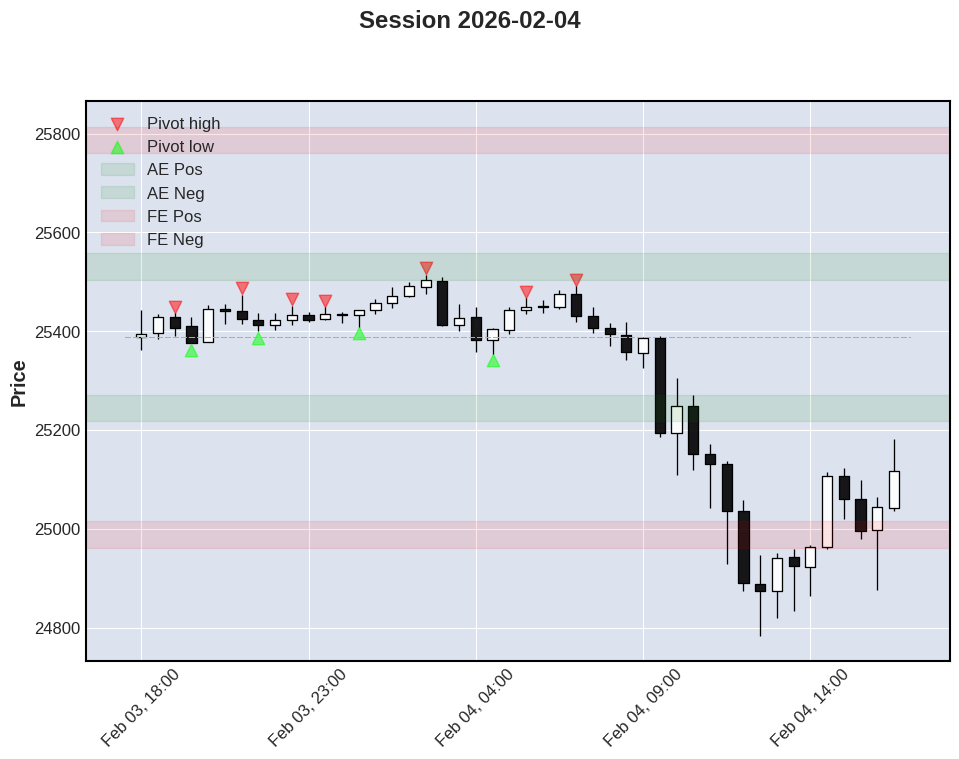

In [8]:
plot_session(date(2026, 2, 4), raw_data, pre_ny_data, aggregated_data)

***

### **Pivot Extraction**
Since we have already assigned the pivots for each candle, we want now to extract those valid pivots into $P_k$:
$$P_k = \begin{cases}
H_k \quad \text{Pivot high}\\
L_k \quad \text{Pivot low}
\end{cases}, \quad s_k \in \{+1, -1\}
$$

In [9]:
pivots = pivot_extraction(pre_ny_data)

print(pivots.columns)

['DateTime', 'Intraday_Session', 'Session', 'P_k', 's_k']


In [10]:
print(pivots.filter(pl.col("Session") == date(2026, 2, 4)))

shape: (11, 5)
┌────────────────────────────────┬──────────────────┬────────────┬──────────┬─────┐
│ DateTime                       ┆ Intraday_Session ┆ Session    ┆ P_k      ┆ s_k │
│ ---                            ┆ ---              ┆ ---        ┆ ---      ┆ --- │
│ datetime[ns, America/New_York] ┆ str              ┆ date       ┆ f64      ┆ i32 │
╞════════════════════════════════╪══════════════════╪════════════╪══════════╪═════╡
│ 2026-02-03 19:00:00 EST        ┆ Asia             ┆ 2026-02-04 ┆ 25435.75 ┆ 1   │
│ 2026-02-03 19:30:00 EST        ┆ Asia             ┆ 2026-02-04 ┆ 25375.75 ┆ -1  │
│ 2026-02-03 21:00:00 EST        ┆ Asia             ┆ 2026-02-04 ┆ 25473.75 ┆ 1   │
│ 2026-02-03 21:30:00 EST        ┆ Asia             ┆ 2026-02-04 ┆ 25399.5  ┆ -1  │
│ 2026-02-03 22:30:00 EST        ┆ Asia             ┆ 2026-02-04 ┆ 25451.75 ┆ 1   │
│ …                              ┆ …                ┆ …          ┆ …        ┆ …   │
│ 2026-02-04 00:30:00 EST        ┆ Asia             ┆ 2026-02

***

### **Price Normalization**
$$\sigma_{Price} = \sigma_{YZ}(d-1) \cdot O_{Ref}$$
$$\pi_k = \frac{P_k - O_{Ref}}{\sigma_{Price}}$$

In [11]:
shifted_aggregated_data = aggregated_data.with_columns(
    pl.col("Sigma_Historical").shift(1).alias("Sigma_Historical")
)
pivots = pivots.join(shifted_aggregated_data, on="Session", how="left")
pivots = pivots.with_columns([
    ((pl.col("P_k") - pl.col("O_Ref")) / (pl.col("Sigma_Historical") * pl.col("O_Ref"))).alias("Pi_k")
])

In [12]:
pivots.drop_nulls().head(5)

DateTime,Intraday_Session,Session,P_k,s_k,O_New York,O_London,O_Asia,H_New York,H_London,H_Asia,L_New York,L_London,L_Asia,C_New York,C_London,C_Asia,O_Ref,Sigma_Historical,Sigma_Today,Z_Body,Z_Sigma,Tau,Direction,_delta_t,Band_AE_Pos_Center,Band_AE_Neg_Center,Band_FE_Pos_Center,Band_FE_Neg_Center,Band_AE_Neg_Upper,Band_AE_Neg_Lower,Band_AE_Pos_Upper,Band_AE_Pos_Lower,Band_FE_Neg_Upper,Band_FE_Neg_Lower,Band_FE_Pos_Upper,Band_FE_Pos_Lower,Pi_k
"datetime[ns, America/New_York]",str,date,f64,i32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
2016-03-01 19:00:00 EST,"""Asia""",2016-03-02,4330.25,-1,4329.0,4341.5,4334.5,4334.75,4349.5,4357.75,4299.25,4326.25,4330.25,4327.0,4329.25,4341.75,4334.5,0.0171,0.006194,0.10217,0.911756,0.41891,"""neutral""",6.670784,4406.991021,4262.008979,4406.991021,4262.008979,4268.679763,4255.338195,4413.661805,4400.320237,4268.679763,4255.338195,4413.661805,4400.320237,-0.05734
2016-03-01 20:00:00 EST,"""Asia""",2016-03-02,4344.5,1,4329.0,4341.5,4334.5,4334.75,4349.5,4357.75,4299.25,4326.25,4330.25,4327.0,4329.25,4341.75,4334.5,0.0171,0.006194,0.10217,0.911756,0.41891,"""neutral""",6.670784,4406.991021,4262.008979,4406.991021,4262.008979,4268.679763,4255.338195,4413.661805,4400.320237,4268.679763,4255.338195,4413.661805,4400.320237,0.134917
2016-03-01 21:00:00 EST,"""Asia""",2016-03-02,4347.75,1,4329.0,4341.5,4334.5,4334.75,4349.5,4357.75,4299.25,4326.25,4330.25,4327.0,4329.25,4341.75,4334.5,0.0171,0.006194,0.10217,0.911756,0.41891,"""neutral""",6.670784,4406.991021,4262.008979,4406.991021,4262.008979,4268.679763,4255.338195,4413.661805,4400.320237,4268.679763,4255.338195,4413.661805,4400.320237,0.178765
2016-03-01 22:00:00 EST,"""Asia""",2016-03-02,4341.75,-1,4329.0,4341.5,4334.5,4334.75,4349.5,4357.75,4299.25,4326.25,4330.25,4327.0,4329.25,4341.75,4334.5,0.0171,0.006194,0.10217,0.911756,0.41891,"""neutral""",6.670784,4406.991021,4262.008979,4406.991021,4262.008979,4268.679763,4255.338195,4413.661805,4400.320237,4268.679763,4255.338195,4413.661805,4400.320237,0.097815
2016-03-02 00:00:00 EST,"""Asia""",2016-03-02,4348.0,-1,4329.0,4341.5,4334.5,4334.75,4349.5,4357.75,4299.25,4326.25,4330.25,4327.0,4329.25,4341.75,4334.5,0.0171,0.006194,0.10217,0.911756,0.41891,"""neutral""",6.670784,4406.991021,4262.008979,4406.991021,4262.008979,4268.679763,4255.338195,4413.661805,4400.320237,4268.679763,4255.338195,4413.661805,4400.320237,0.182138


### **Band Deviation**
To record price location from the band's center, this deviation feature will help quantify dispersion around the band center such that it helps identify statistically significant moves by how close or far is it to the center.

For pivot $k$ and band $j \in \{FE^+, AE^+, FE^-, AE^-\} $:

$$\delta_{j,k} = \frac{P_k - \mu^{\pm}_j}{\sigma_{\text{Price}}}$$

Where:
- $\mu = \text{Band Centers}$



In [13]:
# since Sigma_Historical is already shifted previously prior to the join, we dont need to shift again here
pivots = pivots.with_columns([
    (pl.col("Sigma_Historical") * pl.col("O_Ref")).alias("Sigma_Price")
])

pivots = pivots.with_columns([
    ((pl.col("P_k") - pl.col("Band_FE_Pos_Center")) / pl.col("Sigma_Price")).alias("Delta_FE_Pos"),
    ((pl.col("P_k") - pl.col("Band_AE_Pos_Center")) / pl.col("Sigma_Price")).alias("Delta_AE_Pos"),
    ((pl.col("P_k") - pl.col("Band_FE_Neg_Center")) / pl.col("Sigma_Price")).alias("Delta_FE_Neg"),
    ((pl.col("P_k") - pl.col("Band_AE_Neg_Center")) / pl.col("Sigma_Price")).alias("Delta_AE_Neg"),
])

In [14]:
print(pivots.filter(pl.col("Session") == date(2026, 2, 4)).select(["Session", "P_k", "Delta_FE_Pos", "Delta_AE_Pos", "Delta_FE_Neg", "Delta_AE_Neg", "s_k"]).drop_nulls().head(8))

shape: (8, 7)
┌────────────┬──────────┬──────────────┬──────────────┬──────────────┬──────────────┬─────┐
│ Session    ┆ P_k      ┆ Delta_FE_Pos ┆ Delta_AE_Pos ┆ Delta_FE_Neg ┆ Delta_AE_Neg ┆ s_k │
│ ---        ┆ ---      ┆ ---          ┆ ---          ┆ ---          ┆ ---          ┆ --- │
│ date       ┆ f64      ┆ f64          ┆ f64          ┆ f64          ┆ f64          ┆ i32 │
╞════════════╪══════════╪══════════════╪══════════════╪══════════════╪══════════════╪═════╡
│ 2026-02-04 ┆ 25435.75 ┆ -1.170875    ┆ -0.31565     ┆ 1.492452     ┆ 0.637227     ┆ 1   │
│ 2026-02-04 ┆ 25375.75 ┆ -1.370819    ┆ -0.515594    ┆ 1.292508     ┆ 0.437283     ┆ -1  │
│ 2026-02-04 ┆ 25473.75 ┆ -1.044244    ┆ -0.189019    ┆ 1.619083     ┆ 0.763859     ┆ 1   │
│ 2026-02-04 ┆ 25399.5  ┆ -1.291675    ┆ -0.43645     ┆ 1.371653     ┆ 0.516428     ┆ -1  │
│ 2026-02-04 ┆ 25451.75 ┆ -1.117557    ┆ -0.262332    ┆ 1.545771     ┆ 0.690546     ┆ 1   │
│ 2026-02-04 ┆ 25448.0  ┆ -1.130053    ┆ -0.274828    ┆ 1.533274  

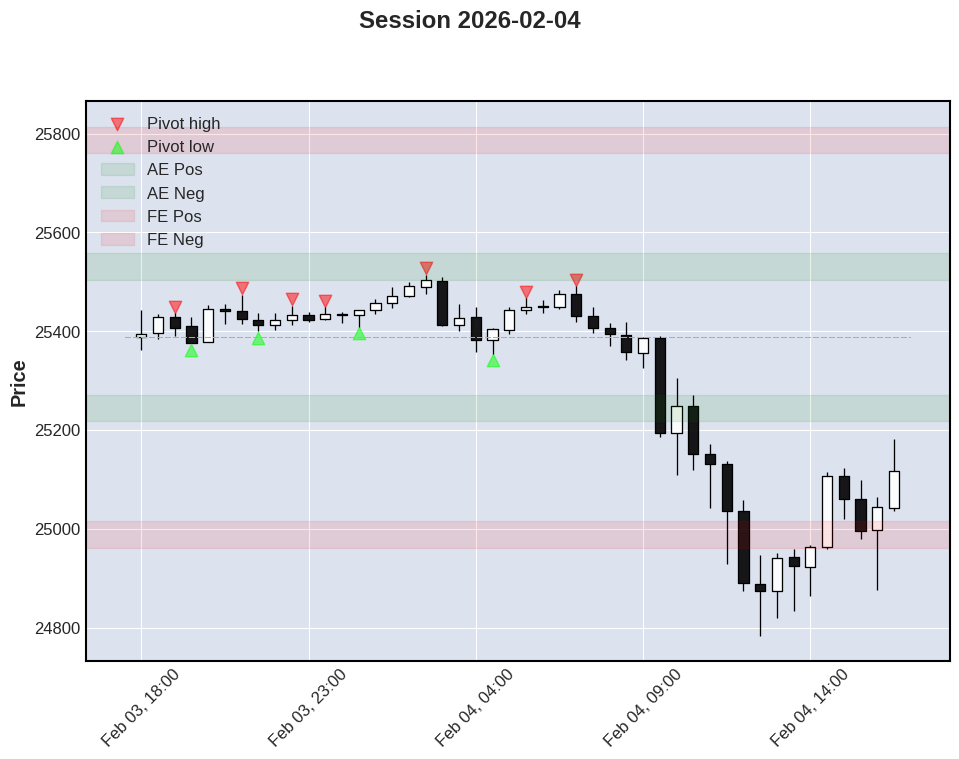

In [15]:
plot_session(date(2026, 2, 4), raw_data, pre_ny_data, aggregated_data)

***

### **Interaction Feature**

#### **State Band Encoding**

For each excursion band $B \in \{AE_{Neg}, AE_{Pos}, FE_{Neg}, FE_{Pos}\}$, the state variable $S_B$ is defined as:

$$
S_B = \begin{cases}
1 & \text{if } B_{\text{lower}} \leq P_k \leq B_{\text{upper}} \\
0 & \text{otherwise}
\end{cases}
$$

where $P_k$ is the current price and $B_{\text{lower}},\ B_{\text{upper}}$ are the lower and upper bounds of band $B$, yielding four state columns:

$$
S_{AE_{Neg}},\quad S_{AE_{Pos}},\quad S_{FE_{Neg}},\quad S_{FE_{Pos}} \quad \in \{0,\ 1\}
$$

In [16]:
pivots = pivots.with_columns([
    ((pl.col("P_k") >= pl.col("Band_AE_Neg_Lower")) & (pl.col("P_k") <= pl.col("Band_AE_Neg_Upper"))).cast(pl.Int8).alias("State_AE_Neg"),
    ((pl.col("P_k") >= pl.col("Band_AE_Pos_Lower")) & (pl.col("P_k") <= pl.col("Band_AE_Pos_Upper"))).cast(pl.Int8).alias("State_AE_Pos"),
    ((pl.col("P_k") >= pl.col("Band_FE_Neg_Lower")) & (pl.col("P_k") <= pl.col("Band_FE_Neg_Upper"))).cast(pl.Int8).alias("State_FE_Neg"),
    ((pl.col("P_k") >= pl.col("Band_FE_Pos_Lower")) & (pl.col("P_k") <= pl.col("Band_FE_Pos_Upper"))).cast(pl.Int8).alias("State_FE_Pos"),
])

In [17]:
print(pivots.filter(pl.col("Session") == date(2026, 2, 4)).select(["Session", "P_k", "State_AE_Neg", "State_AE_Pos", "State_FE_Neg", "State_FE_Pos", "s_k"]).drop_nulls().head(8))

shape: (8, 7)
┌────────────┬──────────┬──────────────┬──────────────┬──────────────┬──────────────┬─────┐
│ Session    ┆ P_k      ┆ State_AE_Neg ┆ State_AE_Pos ┆ State_FE_Neg ┆ State_FE_Pos ┆ s_k │
│ ---        ┆ ---      ┆ ---          ┆ ---          ┆ ---          ┆ ---          ┆ --- │
│ date       ┆ f64      ┆ i8           ┆ i8           ┆ i8           ┆ i8           ┆ i32 │
╞════════════╪══════════╪══════════════╪══════════════╪══════════════╪══════════════╪═════╡
│ 2026-02-04 ┆ 25435.75 ┆ 0            ┆ 0            ┆ 0            ┆ 0            ┆ 1   │
│ 2026-02-04 ┆ 25375.75 ┆ 0            ┆ 0            ┆ 0            ┆ 0            ┆ -1  │
│ 2026-02-04 ┆ 25473.75 ┆ 0            ┆ 0            ┆ 0            ┆ 0            ┆ 1   │
│ 2026-02-04 ┆ 25399.5  ┆ 0            ┆ 0            ┆ 0            ┆ 0            ┆ -1  │
│ 2026-02-04 ┆ 25451.75 ┆ 0            ┆ 0            ┆ 0            ┆ 0            ┆ 1   │
│ 2026-02-04 ┆ 25448.0  ┆ 0            ┆ 0            ┆ 0         

#### **Temporal Dynamics**

To capture movement direction, distance, and speed between the current pivot and the previous pivot within each session.

**Delta move** -> direction and distance from the previous pivot:
$$\Delta P_k = P_k - P_{k-1}$$

**Bar gap** -> number of bars between consecutive pivots:
$$\Delta b_k = \frac{t_k - t_{k-1}}{30\text{ min}}$$



In [18]:
pivots = pivots.with_columns([
    pl.col("Pi_k").shift(1).over("Session").alias("Pi_k_prev"),
    pl.col("DateTime").shift(1).over("Session").alias("DateTime_prev"),
])

pivots = pivots.with_columns([
    (pl.col("Pi_k") - pl.col("Pi_k_prev")).fill_null(0.0).alias("delta_Pi_k"),
    (
        ((pl.col("DateTime") - pl.col("DateTime_prev")).dt.total_minutes() / 30)
        .fill_null(0)
        .cast(pl.Int16)
    ).alias("delta_b_k"),
])

**Pivot-to-pivot speed** -> normalized by bar gap:
$$v_k = \begin{cases} \dfrac{\Delta P_k}{\Delta b_k}, & \Delta b_k > 0 \\ 0, & \text{otherwise} \end{cases}$$

**Movement direction** -> sign of the move:
$$\text{dir}_k = \operatorname{sign}(\Delta P_k) \in \{-1, 0, +1\}$$

**Reversal flag** -> 1 if direction changed from the previous move:
$$\text{turn}_k = \mathbf{1}\!\left[\operatorname{sign}(\Delta P_k) \neq \operatorname{sign}(\Delta P_{k-1})\right]$$

In [19]:
pivots = pivots.with_columns([
    pl.when(pl.col("delta_b_k") > 0)
    .then(pl.col("delta_Pi_k") / pl.col("delta_b_k"))
    .otherwise(0.0)
    .alias("Speed_k"),

    pl.when(pl.col("delta_Pi_k") > 0).then(pl.lit(1))
    .when(pl.col("delta_Pi_k") < 0).then(pl.lit(-1))
    .otherwise(pl.lit(0))
    .alias("Dir_k"),
])

pivots = pivots.with_columns([
    pl.col("Dir_k").shift(1).over("Session").fill_null(0).alias("Dir_prev"),
]).with_columns([
    ((pl.col("Dir_k") != pl.col("Dir_prev")) & (pl.col("Dir_k") != 0) & (pl.col("Dir_prev") != 0))
    .cast(pl.Int8)
    .alias("Turn_k")
]).drop(["Pi_k_prev", "DateTime_prev", "Dir_prev"])

In [20]:
pivots.filter(pl.col("Session") == date(2026, 2, 4)).select([
    "DateTime", "delta_Pi_k", "delta_b_k", "Speed_k", "Dir_k", "Turn_k", "P_k", "s_k"
]).head(8)

DateTime,delta_Pi_k,delta_b_k,Speed_k,Dir_k,Turn_k,P_k,s_k
"datetime[ns, America/New_York]",f64,i16,f64,i32,i8,f64,i32
2026-02-03 19:00:00 EST,0.0,0,0.0,0,0,25435.75,1
2026-02-03 19:30:00 EST,-0.199944,1,-0.199944,-1,0,25375.75,-1
2026-02-03 21:00:00 EST,0.326576,3,0.108859,1,1,25473.75,1
2026-02-03 21:30:00 EST,-0.247431,1,-0.247431,-1,1,25399.5,-1
2026-02-03 22:30:00 EST,0.174118,2,0.087059,1,1,25451.75,1
2026-02-03 23:30:00 EST,-0.012497,2,-0.006248,-1,1,25448.0,1
2026-02-04 00:30:00 EST,-0.130797,2,-0.065398,-1,0,25408.75,-1
2026-02-04 02:30:00 EST,0.351569,4,0.087892,1,1,25514.25,1


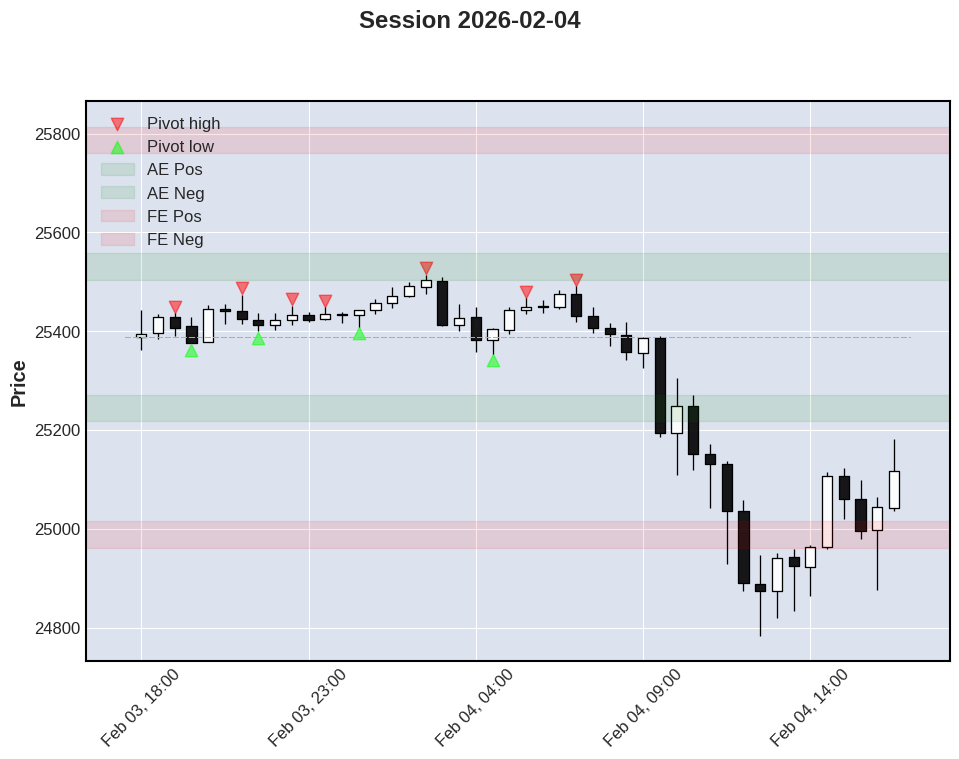

In [21]:
plot_session(date(2026, 2, 4), raw_data, pre_ny_data, aggregated_data)

***